In [105]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

In [125]:
paths = [
    'runs/newbase/nobehav64_seed0/model_weights.pth',
    'runs/newbase/nobehav64_seed42/model_weights.pth',
    'runs/newbase/nobehav64_seed123/model_weights.pth',
]

real_img, _, _, = next(iter(dataloaders['train'][data_keys[0]]))

Rws = []
Rs = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path))
    model.to(device);
    model.train();

    feature_maps = []

    for _ in range(200):
        syn_img = (torch.rand_like(real_img) - 0.5) * (12 ** 0.5)  # Zero mean and unit variance
        
        features = model.core(syn_img)[:, :, 10:15, 24:29].detach().cpu()
        feature_maps.append(features)

    features = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

    X = features
    Xc = X - X.mean(dim=0, keepdim=True)
    cov = Xc.T @ Xc / (X.shape[0] - 1)

    L = torch.linalg.cholesky(cov)
    Winv = L.T

    R = torch.cat([model.readout[key].features.squeeze().detach().cpu().T for key in data_keys])
    Rw = R @ Winv.T
    
    Rws.append(Rw)
    Rs.append(R)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [126]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

def get_ari_curve(n_clusters_range, all_features):
    def cluster(points, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(points)
        return labels
    
    mean_curve = []
    std_curve = []
    for n in n_clusters_range:
        labels = [cluster(features, n) for features in all_features]

        x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
        aris = np.array([
            adjusted_rand_score(labels[x], labels[y]) for x, y in zip(x_idcs, y_idcs)
        ])

        ari_mean = aris.mean()
        ari_std = aris.std(ddof=1)
        mean_curve.append(ari_mean)
        std_curve.append(ari_std)
    
    return mean_curve, std_curve

In [127]:
k_range = np.unique(np.geomspace(1, 100, num=5, dtype=int))
Rw_curve = get_curve(k_range, Rws)
R_curve = get_curve(k_range, Rs)

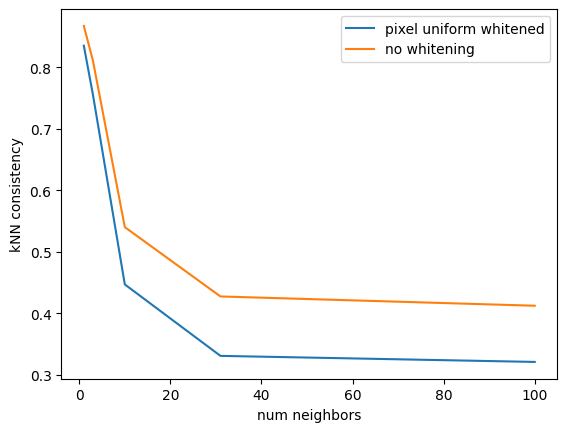

In [131]:
plt.plot(k_range, Rw_curve[0], label='pixel uniform whitened')
plt.plot(k_range, R_curve[0], label='no whitening')
plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend()
plt.show()